The code provides a step-by-step process to perform a flood risk analysis based on multi-criteria environmental factors using a
Random Forest Machine Learning. We extract a set of flood hazard triggers and exposure data from open-source datasets and satellite remote sensing.

The selected flood triggers include:
1. Elevation
2. Slope gradient
3. Topographic wetness index (TWI)
4. Flow accumulation
5. Soil type
6. Drainage density
7. Distance from rivers
8. Distance from roads
9. Land cover/use
10. Population density
11. Long-term mean wet season precipitation

In [1]:
# Import libraries for geodata processing and handling
import warnings
import rasterio
from rasterio.warp import reproject, Resampling
import geopandas as gpd
import numpy as np
import pandas as pd
import os
import shap

# Import libraries for model training, parameter tuning and model evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
# Paths
raster_path = r"D:\Shey_flood risks\predictors"

rasters = [
    "Elevation.tif",
    "slope.tif",
    "soil_type.tif",
    "TWI.tif",
    "flowacc.tif",
    "drainage_den.tif",
    "Dist_roads.tif",
    "dist_rivers.tif",
    "landuse.tif",
    "Population.tif",
    "precipitation.tif"
]

shapefile = r"D:\Shey_flood risks\predictors\labels.shp"

# Load points
points = gpd.read_file(shapefile)

In [3]:
# Let's read the labels and see
points = gpd.read_file(shapefile)
print(points.head())

   OBJECTID  Id  Labels                       geometry
0         1   0     1.0  POINT (631325.286 660936.076)
1         2   0     1.0  POINT (631454.494 660870.583)
2         3   0     1.0    POINT (631249.11 660838.57)
3         4   0     1.0  POINT (631568.012 660752.439)
4         5   0     1.0  POINT (631367.033 661120.328)


The labels are georeferenced and derived from very high-resolution Google Earth imagery and field surveys of historical flood sites and floodplains in the Bamenda urban area. The labels are coded: 1 = flood and 0 = no flood.

In [4]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load points
points = gpd.read_file(shapefile)

# Remove invalid or empty geometries
points = points[points.geometry.notnull()]
points = points[~points.geometry.is_empty]

# Remove points with invalid coordinates
points = points[
    np.isfinite(points.geometry.x) &
    np.isfinite(points.geometry.y)
]

# Create empty dataframe
data = pd.DataFrame()

# Extract values from each raster
for r in rasters:
    raster_file = os.path.join(raster_path, r)
    print(f"Processing: {r}")

    with rasterio.open(raster_file) as src:

        # Ensure CRS match
        if points.crs != src.crs:
            points = points.to_crs(src.crs)

        # Get coordinates
        coords = [(x, y) for x, y in zip(points.geometry.x, points.geometry.y)]

        # Sample raster
        values = []
        for v in src.sample(coords):
            val = v[0]

            # Handle nodata values
            if val == src.nodata:
                val = np.nan

            values.append(val)

        # Store values
        data[r.replace(".tif", "")] = values

# Add label column
data["label"] = points["Labels"].astype(int)

# Clean data
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

Processing: Elevation.tif
Processing: slope.tif
Processing: soil_type.tif
Processing: TWI.tif
Processing: flowacc.tif
Processing: drainage_den.tif
Processing: Dist_roads.tif
Processing: dist_rivers.tif
Processing: landuse.tif
Processing: Population.tif
Processing: precipitation.tif


In [5]:
# Preview
print(data.head())
print(data["label"].value_counts())
print(data.shape)

# Save for later
output_csv = r"D:\Shey_flood risks\RFtraining_data.csv"
data.to_csv(output_csv, index=False)
print(f"Training data saved to: {output_csv}")

   Elevation     slope  soil_type        TWI  flowacc  drainage_den  \
0     1238.0  1.350224        2.0   9.713918     12.0      5.111943   
1     1241.0  2.385944        2.0   8.188689      4.0      4.260517   
2     1242.0  1.687605        2.0   6.925825      0.0      3.606297   
3     1242.0  3.338470        2.0   9.015368     15.0      4.251495   
4     1239.0  2.719923        2.0  10.542414     59.0      6.933196   

   Dist_roads  dist_rivers  landuse  Population  precipitation  label  
0   90.000000     0.000000     48.0   17.327326     319.871613      1  
1   30.000000     0.000000     59.0   17.648611     319.871613      1  
2   67.082039    42.426407     48.0   35.396832     319.871613      1  
3   42.426407     0.000000     59.0   23.534309     319.871613      1  
4   84.852814    67.082039      1.0   23.133236     319.871613      1  
label
1    143
0    139
Name: count, dtype: int64
(282, 12)
Training data saved to: D:\Shey_flood risks\RFtraining_data.csv


In [6]:
data.head()

,Elevation,slope,soil_type,TWI,flowacc,drainage_den,Dist_roads,dist_rivers,landuse,Population,precipitation,label
0,1238.0,1.350224,2.0,9.713918,12.0,5.111943,90.000000,0.000000,48.0,17.327326,319.871613,1
1,1241.0,2.385944,2.0,8.188689,4.0,4.260517,30.000000,0.000000,59.0,17.648611,319.871613,1
2,1242.0,1.687605,2.0,6.925825,0.0,3.606297,67.082039,42.426407,48.0,35.396832,319.871613,1
3,1242.0,3.338470,2.0,9.015368,15.0,4.251495,42.426407,0.000000,59.0,23.534309,319.871613,1
4,1239.0,2.719923,2.0,10.542414,59.0,6.933196,84.852814,67.082039,1.0,23.133236,319.871613,1


From here, we can build the Random Forest Model, splitting the data into training (70%) and test (30%) sets. Then tuning the hyperparameters using GridSearchCV, and 5-folds fitting, and select the best model. 

In [7]:
# The RF model structure and construction

# Loading training data
data = pd.read_csv(r"D:\Shey_flood risks\RFtraining_data.csv")

# Features and target
X = data.drop(columns=["label"])
y = data["label"]

# Splitting the data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='roc_auc',
    verbose=2
)

print(" Running GridSearchCV for hyperparameter tuning...")
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
print("\n Best hyperparameters:")
print(grid_search.best_params_)

 Running GridSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 Best hyperparameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}



Confusion Matrix:
 [[41  1]
 [ 3 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.98      0.93      0.95        43

    accuracy                           0.95        85
   macro avg       0.95      0.95      0.95        85
weighted avg       0.95      0.95      0.95        85


ROC AUC: 0.9955703211517165


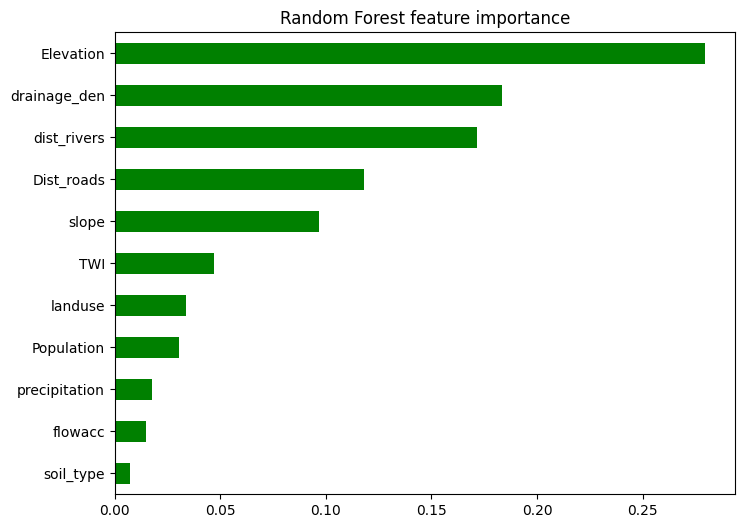

In [8]:
# Model elevation, feature importance/contribution assessment

# Evaluate on test set
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]  # probability of flood (1)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

# Feature importance and visualization
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(8,6))
feat_importances.plot(kind="barh", color="green")
plt.title("Random Forest feature importance")
plt.show()

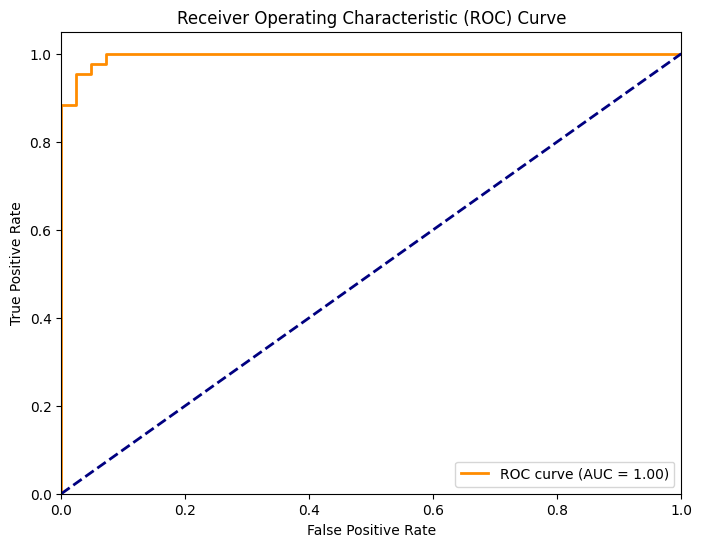

In [9]:
# Predicted probabilities
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Plot ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

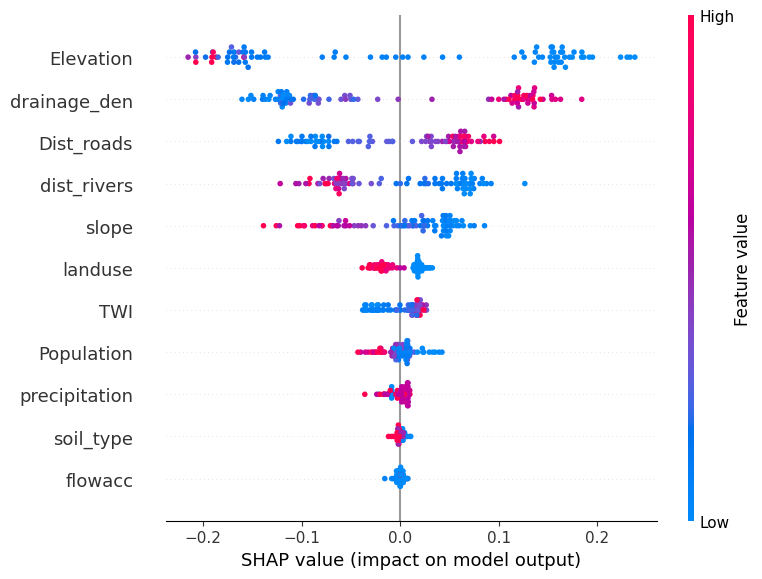

In [10]:
X_test_numeric = X_test.astype(float)

# SHAP Explainer
explainer = shap.Explainer(best_rf, X_test_numeric)

# SHAP values
shap_values = explainer(X_test_numeric)

# Only keep class-specific SHAP (flood = 1)
shap_values_class1 = shap_values.values[:, :, 1]  # shape: (n_samples, n_features)
shap.summary_plot(shap_values_class1, X_test_numeric, feature_names=X_test_numeric.columns)

In [11]:
# Build full paths
feature_files = [os.path.join(raster_path, f) for f in rasters]

# Check which files exist
for f in feature_files:
    print(f, "->", "Exists" if os.path.exists(f) else "Missing")

D:\Shey_flood risks\predictors\Elevation.tif -> Exists
D:\Shey_flood risks\predictors\slope.tif -> Exists
D:\Shey_flood risks\predictors\soil_type.tif -> Exists
D:\Shey_flood risks\predictors\TWI.tif -> Exists
D:\Shey_flood risks\predictors\flowacc.tif -> Exists
D:\Shey_flood risks\predictors\drainage_den.tif -> Exists
D:\Shey_flood risks\predictors\Dist_roads.tif -> Exists
D:\Shey_flood risks\predictors\dist_rivers.tif -> Exists
D:\Shey_flood risks\predictors\landuse.tif -> Exists
D:\Shey_flood risks\predictors\Population.tif -> Exists
D:\Shey_flood risks\predictors\precipitation.tif -> Exists


In [12]:
# Build full paths
raster_path = r"D:\Shey_flood risks\predictors"
rasters = [
    "Elevation.tif",
    "slope.tif",
    "soil_type.tif",
    "TWI.tif",
    "flowacc.tif",
    "drainage_den.tif",
    "Dist_roads.tif",
    "dist_rivers.tif",
    "landuse.tif",
    "Population.tif",
    "precipitation.tif"
]
feature_files = [os.path.join(raster_path, r) for r in rasters]

# Read the first raster as reference
with rasterio.open(feature_files[0]) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = (ref.height, ref.width)
    ref_crs = ref.crs
    ref_transform = ref.transform

# Load & align all rasters
rasters_data = []
for f in feature_files:
    with rasterio.open(f) as src:
        data = src.read(1).astype(np.float32)
        
        # Check shape
        if data.shape != ref_shape:
            # Resample to reference raster
            resampled = np.empty(ref_shape, dtype=np.float32)
            reproject(
                source=data,
                destination=resampled,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.bilinear
            )
            data = resampled
        
        rasters_data.append(data.flatten())

# Stack into feature matrix
X_raster = np.stack(rasters_data, axis=1)
print("Raster matrix shape:", X_raster.shape)

Raster matrix shape: (243024, 11)


In [13]:
# Predict flood probability (flood=1)
y_raster_prob = best_rf.predict_proba(X_raster)[:, 1]  # probability of flood

# Reshape to raster dimensions
flood_prob_raster = y_raster_prob.reshape(ref_shape)
print("Flood probability raster shape:", flood_prob_raster.shape)

C:\Users\rfoke\PycharmProjects\pythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Flood probability raster shape: (498, 488)


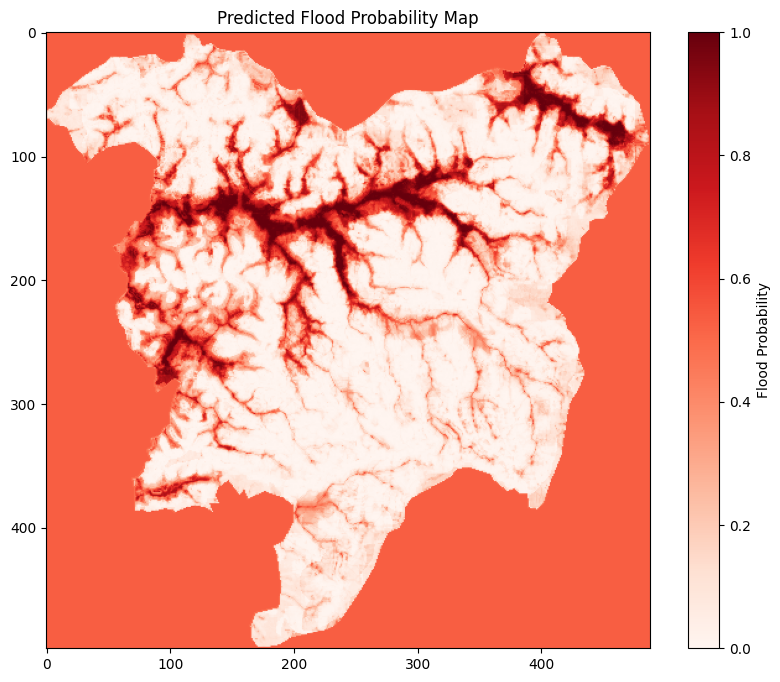

In [14]:
# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(flood_prob_raster, cmap="Reds")
plt.colorbar(label="Flood Probability")
plt.title("Predicted Flood Probability Map")
plt.show()